# Mock 04 — fixed version

Each fix is marked **Fix N** and numbered as in `mock_04_solution.md`. The mechanics are corrected
first; the last section asks whether the corrected result should be believed at all.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

pd.set_option("display.width", 120)

df = pd.read_csv("../../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
assert df.index.is_monotonic_increasing and df.index.is_unique

# Fix 1: prices can be negative or ~0, so pct_change is meaningless; work in EUR/MWh changes
df["chg"] = df["price_eur_mwh"].diff()
pct = df["price_eur_mwh"].pct_change()
print("prices <= 0:", (df["price_eur_mwh"] <= 0).sum(), "  |price| < 5:", (df["price_eur_mwh"].abs() < 5).sum())
print("pct_change extremes:", pct.min().round(1), pct.max().round(1), "   diff extremes:", df["chg"].min(), df["chg"].max())

prices <= 0: 43   |price| < 5: 27
pct_change extremes: -272.7 37.6    diff extremes: -255.7 253.99


**Fix 2 / 3 — target is the *future* change; features use information up to and including `t`.**
`chg.shift(-1)` is the change from `t` to `t+1`. `rolling(24)` over `chg` ending at `t` is fine
(it only contains changes up to `t`); it was a leak in the broken notebook only because the
target there was `chg[t-1]`, which sits inside the window.

In [2]:
df["target"] = df["chg"].shift(-1)
df["target_6h"] = df["price_eur_mwh"].shift(-6) - df["price_eur_mwh"]
df["mom24"] = df["chg"].rolling(24).mean()
df["vol24"] = df["chg"].rolling(24).std()
df["chg_lag0"] = df["chg"]
df["load_chg"] = df["consumption_mwh"].diff()
df["hour"] = df.index.hour

features = ["mom24", "vol24", "chg_lag0", "load_chg", "hour"]
d = df.dropna(subset=features + ["target", "target_6h"])
print(len(d), "rows")

17490 rows


**Fix 4 / 5 — chronological split, scaler fitted on train only.**

In [3]:
split = int(len(d) * 0.8)
train, test = d.iloc[:split], d.iloc[split:]
print("train:", train.index.min().date(), "->", train.index.max().date(), "| test:", test.index.min().date(), "->", test.index.max().date())

scaler = StandardScaler().fit(train[features])
X_train = scaler.transform(train[features]); X_test = scaler.transform(test[features])
y_train = train["target"].values;             y_test = test["target"].values

model = LinearRegression().fit(X_train, y_train)
coefs = pd.Series(model.coef_, index=features).round(3)
print(coefs)
print(f"R2 train {model.score(X_train, y_train):.3f} | R2 test {model.score(X_test, y_test):.3f}")

train: 2022-01-02 -> 2023-08-07 | test: 2023-08-08 -> 2023-12-31
mom24      -5.694
vol24      -1.203
chg_lag0   -8.017
load_chg    8.820
hour       -0.133
dtype: float64
R2 train 0.270 | R2 test 0.298


**Fix 5 (cont.) — the 6h target overlaps: adjacent labels share 5 of 6 hours, so shuffled KFold
leaks. Use `TimeSeriesSplit` with a gap of at least the horizon.**

In [4]:
tscv = TimeSeriesSplit(n_splits=5, gap=6)
cv_ts = cross_val_score(LinearRegression(), X_train, train["target_6h"].values, cv=tscv)
from sklearn.model_selection import KFold
cv_kf = cross_val_score(LinearRegression(), X_train, train["target_6h"].values, cv=KFold(5, shuffle=True, random_state=0))
print("6h target, shuffled KFold R2 :", cv_kf.round(3), "mean", cv_kf.mean().round(3))
print("6h target, TimeSeriesSplit R2:", cv_ts.round(3), "mean", cv_ts.mean().round(3))

6h target, shuffled KFold R2 : [0.359 0.312 0.331 0.315 0.333] mean 0.33
6h target, TimeSeriesSplit R2: [0.236 0.328 0.419 0.343 0.285] mean 0.322


**Fix 6 / 7 / 8 / 9 — realistic P&L.** The signal formed at `t` earns the change from `t` to `t+1`
(the target), not the change that has already happened. Hourly data is annualised with
`sqrt(8760)`. A transaction cost is charged on every change of position. Hit rate is measured on
the test set and excludes hours where the realised change is exactly zero.

In [5]:
pred = model.predict(X_test)
signal = pd.Series(np.sign(pred), index=test.index)
realised = test["target"]                       # change from t to t+1

gross = signal * realised
turnover = signal.diff().abs().fillna(np.abs(signal.iloc[0]))   # units traded each hour
cost_per_unit = 1.0                                             # EUR/MWh, round-trip charged per unit traded
net = gross - cost_per_unit * turnover

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(8760)

nonzero = realised != 0
hit = (np.sign(pred[nonzero.values]) == np.sign(realised[nonzero])).mean()

print(f"Sharpe gross (sqrt 8760): {sharpe(gross):6.2f}")
print(f"Sharpe net of {cost_per_unit} EUR/MWh: {sharpe(net):6.2f}")
print(f"Hit rate (test, non-zero): {hit:.1%}")
print(f"turnover: position changes in {turnover.gt(0).mean():.0%} of hours")
print(f"same gross Sharpe with the broken sqrt(24*252) factor: {gross.mean()/gross.std()*np.sqrt(24*252):.2f}")

Sharpe gross (sqrt 8760):  32.03
Sharpe net of 1.0 EUR/MWh:  28.62
Hit rate (test, non-zero): 66.7%
turnover: position changes in 43% of hours
same gross Sharpe with the broken sqrt(24*252) factor: 26.61


**Fix 10 — where does the P&L come from?** Concentration by hour and by period.

In [6]:
top = gross.sort_values(ascending=False)
share_top1 = top.iloc[: len(top) // 100].sum() / gross.sum()
print(f"top 1% of hours contribute {share_top1:.0%} of gross P&L")
print()
print("gross P&L by month:")
print(gross.resample("MS").sum().round(0).to_string())

top 1% of hours contribute 18% of gross P&L

gross P&L by month:
time
2023-08-01 00:00:00+00:00    5405.0
2023-09-01 00:00:00+00:00    5372.0
2023-10-01 00:00:00+00:00    5896.0
2023-11-01 00:00:00+00:00    5222.0
2023-12-01 00:00:00+00:00    7045.0
Freq: MS


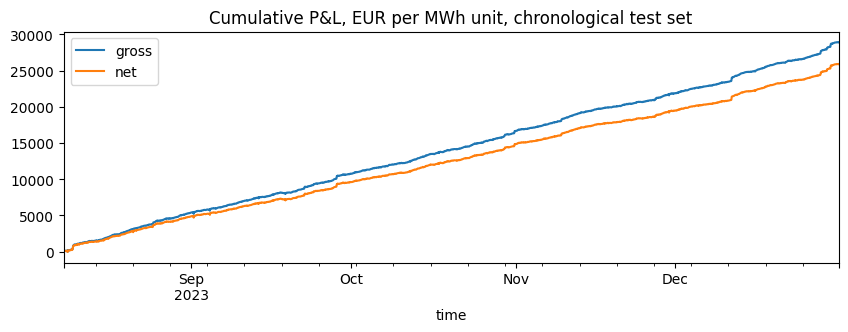

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
ax = pd.DataFrame({"gross": gross.cumsum(), "net": net.cumsum()}).plot(figsize=(10, 3), title="Cumulative P&L, EUR per MWh unit, chronological test set")
plt.show()

## Do you believe the corrected result?

The mechanics are now honest and the numbers are still strong. That is the moment to ask why.

1. **The series is strongly mean-reverting at one hour.** The synthetic price is a smooth component
   plus independent hourly noise, so consecutive changes are negatively autocorrelated (below).
   A negative `chg_lag0` coefficient is not "momentum", it is noise reversal. On real data you
   would test whether this survives across years and across different price regimes.
2. **Day-ahead prices are not tradable hour by hour.** All 24 hourly prices for D+1 are set in one
   auction around 12:00 on day D. A position "entered at 15:00 and closed at 16:00" does not exist
   in that market; the realistic version of this idea is a once-a-day decision, or an intraday /
   imbalance price series.
3. **Costs and constraints.** A 1 EUR/MWh cost already removes part of the edge; imbalance
   charges, bid-offer spread and position limits are not modelled at all.

In [8]:
ac1 = d["chg"].autocorr(1)
print(f"lag-1 autocorrelation of hourly price changes: {ac1:.2f}  (iid noise on a smooth level gives about -0.5)")
by_month = gross.resample("MS").apply(sharpe).round(1)
print("gross Sharpe by test month:", by_month.to_dict().values())
print("months with positive gross P&L:", (gross.resample("MS").sum() > 0).sum(), "of", gross.resample("MS").sum().size)

lag-1 autocorrelation of hourly price changes: -0.29  (iid noise on a smooth level gives about -0.5)
gross Sharpe by test month: dict_values([31.2, 25.8, 36.6, 33.2, 36.1])
months with positive gross P&L: 5 of 5
